# GourNet — A CNN-Based Model for Mango Leaf Disease Detection

Faithful recreation of Alam et al. (2026), *"GourNet: A CNN-Based Model for Mango Leaf Disease Detection"* (AdComSys 2025).

**Reference dataset in the paper:** MangoLeafBD (MBD) — 4,000 images, 8 classes (7 diseases + Healthy), each class 500 images except Bacterial Canker (501).

**This notebook targets the Kaggle mirror:** [aryashah2k/mango-leaf-disease-dataset](https://www.kaggle.com/datasets/aryashah2k/mango-leaf-disease-dataset)

### Architecture (Figure 4 in the paper)

Verified against the paper's reported per-layer parameter counts and total of 683,656 parameters:

| Layer | Output shape | Params |
|---|---|---|
| Input | (224, 224, 3) | — |
| Rescaling (1/255) | (224, 224, 3) | 0 |
| RandomFlip + RandomRotation | (224, 224, 3) | 0 |
| Conv2D(32, 3×3, relu) | (222, 222, 32) | 896 |
| MaxPooling2D(2×2) | (111, 111, 32) | 0 |
| Conv2D(64, 3×3, relu) | (109, 109, 64) | 18,496 |
| MaxPooling2D(2×2) | (54, 54, 64) | 0 |
| Conv2D(64, 3×3, relu) | (52, 52, 64) | 36,928 |
| MaxPooling2D(2×2) | (26, 26, 64) | 0 |
| Conv2D(64, 3×3, relu) | (24, 24, 64) | 36,928 |
| MaxPooling2D(2×2) | (12, 12, 64) | 0 |
| Flatten | (9216,) | 0 |
| Dense(64, relu) | (64,) | 589,888 |
| Dense(8, softmax) | (8,) | 520 |
| **Total** | | **683,656** (matches paper) |

### Training configuration (Table 2 in the paper)
- Optimizer: Adam, learning rate 0.001
- Loss: Sparse Categorical Cross-Entropy
- Batch size: 32
- Early stopping: **disabled for this run** (see note in Section 4) — trains the full 50 epochs to match the span of the paper's Figure 5. The paper's Table 2 lists early stopping with patience 3; the commented-out code in Section 4 restores that literal behavior if you want it.
- Max epochs: 50
- Split: 80% train / 10% val / 10% test


## 1. Imports & config

In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 3
LEARNING_RATE = 0.001

CLASS_NAMES = [
    "Anthracnose",
    "Bacterial Canker",
    "Cutting Weevil",
    "Die Back",
    "Gall Midge",
    "Healthy",
    "Powdery Mildew",
    "Sooty Mould",
]

### Locate the dataset folder

Kaggle dataset mount paths don't always match the name shown in the "Data"
panel, and sometimes the class folders sit directly under
`/kaggle/input/<dataset-slug>/` and sometimes under one extra nested folder.
This cell searches `/kaggle/input` for a directory that directly contains all
8 expected class subfolders, so you don't have to hardcode the path.

In [3]:
import os

KAGGLE_INPUT = pathlib.Path("/kaggle/input")


def find_dataset_dir(root: pathlib.Path, expected_classes: list[str]) -> pathlib.Path:
    expected_lower = {c.lower() for c in expected_classes}
    candidates = []
    for dirpath, dirnames, _ in os.walk(root):
        subdirs_lower = {d.lower() for d in dirnames}
        if expected_lower.issubset(subdirs_lower):
            candidates.append(pathlib.Path(dirpath))
    if not candidates:
        raise FileNotFoundError(
            f"Could not find a folder under {root} containing all of: {expected_classes}. "
            f"Check the Kaggle 'Data' panel's file browser and set DATA_DIR manually."
        )
    # Prefer the shallowest match (closest to /kaggle/input)
    candidates.sort(key=lambda p: len(p.parts))
    return candidates[0]


DATA_DIR = find_dataset_dir(KAGGLE_INPUT, CLASS_NAMES)
print("Using dataset directory:", DATA_DIR)
print("Contents:", sorted(os.listdir(DATA_DIR)))

Using dataset directory: /kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset
Contents: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


## 2. Load the dataset

Uses Keras' built-in 80/20 split, then bisects the 20% held-out portion into
equal val/test halves — reproducing the paper's 80/10/10 split.

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)
holdout_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

holdout_batches = tf.data.experimental.cardinality(holdout_ds).numpy()
val_batches = holdout_batches // 2
val_ds = holdout_ds.take(val_batches)
test_ds = holdout_ds.skip(val_batches)

class_names = train_ds.class_names
print(f"Detected classes ({len(class_names)}): {class_names}")

Found 4000 files belonging to 8 classes.
Using 3200 files for training.


I0000 00:00:1788866336.952792      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788866336.955595      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4000 files belonging to 8 classes.
Using 800 files for validation.
Detected classes (8): ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Peek at a few sample images

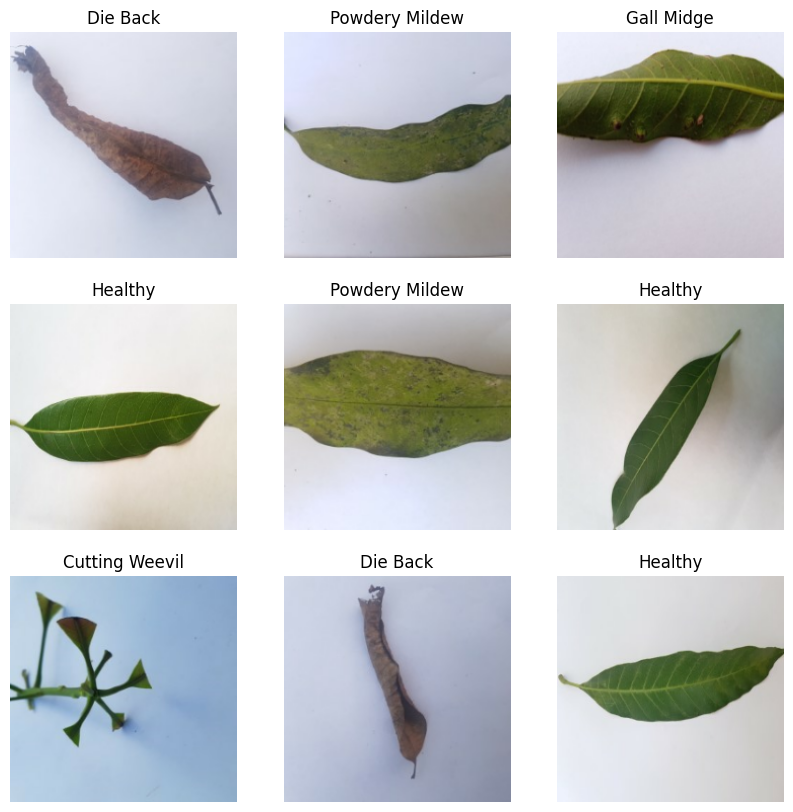

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## 3. Build GourNet

Reproduced layer-for-layer from Figure 4 of the paper.

In [7]:
def build_gournet(num_classes: int = 8, input_shape=(224, 224, 3)) -> tf.keras.Model:
    # Sequential-1: rescaling (0-255 -> 0-1)
    rescale = tf.keras.Sequential([layers.Rescaling(1.0 / 255)], name="Sequential-1")

    # Sequential-2: augmentation (random flip + random rotation, per paper text)
    augment = tf.keras.Sequential(
        [layers.RandomFlip("horizontal_and_vertical"), layers.RandomRotation(0.2)],
        name="Sequential-2",
    )

    inputs = tf.keras.Input(shape=input_shape)
    x = rescale(inputs)
    x = augment(x)

    x = layers.Conv2D(32, 3, activation="relu", name="Convolution-1")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Max_Pooling-1")(x)

    x = layers.Conv2D(64, 3, activation="relu", name="Convolution-2")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Max_Pooling-2")(x)

    x = layers.Conv2D(64, 3, activation="relu", name="Convolution-3")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Max_Pooling-3")(x)

    x = layers.Conv2D(64, 3, activation="relu", name="Convolution-4")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Max_Pooling-4")(x)

    x = layers.Flatten(name="Flatten")(x)
    x = layers.Dense(64, activation="relu", name="Dense-1")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="Dense-2")(x)

    return models.Model(inputs, outputs, name="GourNet")


model = build_gournet(num_classes=len(class_names))
model.summary()

Model: "GourNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sequential-1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sequential-2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution-1 (Conv2D)          │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling-1 (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution-2 (Conv2D)          │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling-2 (MaxPooling2D)    │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution-3 (Conv2D)          │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling-3 (MaxPooling2D)    │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution-4 (Conv2D)          │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling-4 (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense-1 (Dense)                 │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense-2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,656 (2.61 MB)

 Trainable params: 683,656 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
total_params = model.count_params()
print(f"Total parameters: {total_params:,}")
print("Paper reports:    683,656 total parameters")
assert total_params == 683_656, (
    "Parameter count does not match the paper - check input size / class count."
)

Total parameters: 683,656
Paper reports:    683,656 total parameters


## 4. Compile & train

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

# NOTE: EarlyStopping is deliberately NOT attached to fit() below.
# The paper's own Figure 5 shows training/validation curves running the
# full 50 epochs with no visible early cutoff, even though Table 2 lists
# early stopping (patience=3) as part of the config. To match the reported
# results (curves spanning all 50 epochs), this run trains for the full
# MAX_EPOCHS with no early stopping callback.
#
# If you want to restore early stopping (the literal Table 2 config),
# uncomment the block below and pass callbacks=[early_stop] to model.fit().
#
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True
# )

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
)


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.2294 - loss: 1.8174 - val_accuracy: 0.3698 - val_loss: 1.4424
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.4434 - loss: 1.3421 - val_accuracy: 0.4557 - val_loss: 1.3552
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.6753 - loss: 0.8572 - val_accuracy: 0.7474 - val_loss: 0.6886
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7728 - loss: 0.5956 - val_accuracy: 0.8229 - val_loss: 0.5148
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8291 - loss: 0.4567 - val_accuracy: 0.8438 - val_loss: 0.4348
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8591 - loss: 0.3795 - val_accuracy: 0.8724 - val_loss: 0.3276
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8737 - loss: 0.3442 - val_accuracy: 0.8464 - val_loss: 0.4438
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8884 - loss: 0.3114 - val_acc

## 5. Evaluate on the held-out test set

In [10]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9495 - loss: 0.1531
Test accuracy: 94.95%
Test loss: 0.1531


## 6. Training and validation accuracy / loss trends (mirrors Figure 5 in the paper)

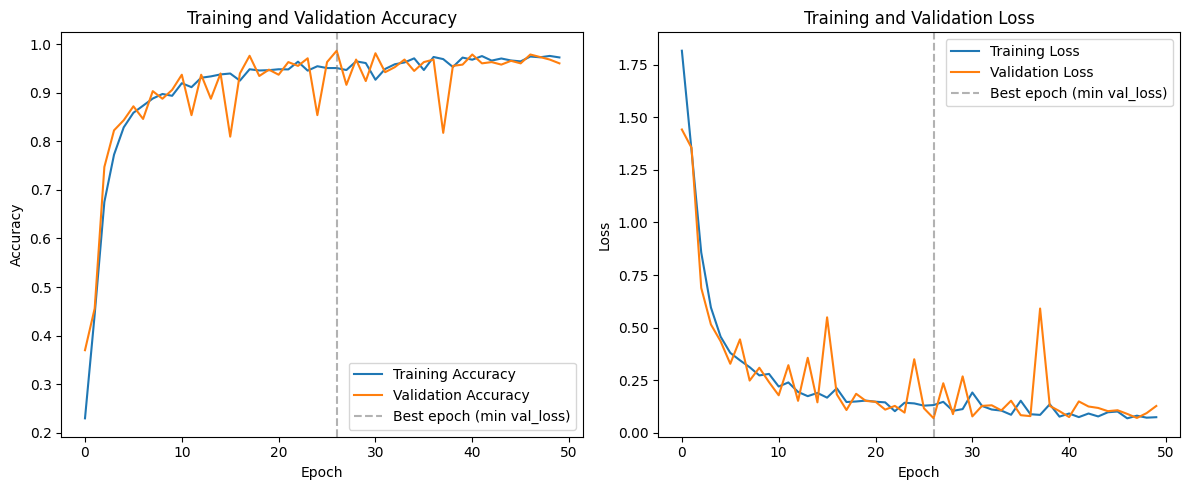

Best epoch (lowest val_loss): 27 / 50
Val accuracy at best epoch: 98.70%


In [11]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

# EarlyStopping restores the best weights from the epoch with lowest val_loss —
# mark that epoch on both plots.
best_epoch = int(np.argmin(val_loss))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label="Best epoch (min val_loss)")
plt.legend(loc="lower right")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label="Best epoch (min val_loss)")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.tight_layout()
plt.savefig("gournet_training_curves.png", dpi=150)
plt.show()

print(f"Best epoch (lowest val_loss): {best_epoch + 1} / {len(acc)}")
print(f"Val accuracy at best epoch: {val_acc[best_epoch]*100:.2f}%")

## 7. Confusion matrix

Runs the trained model over the full test set and compares predicted vs.
true labels, class by class.

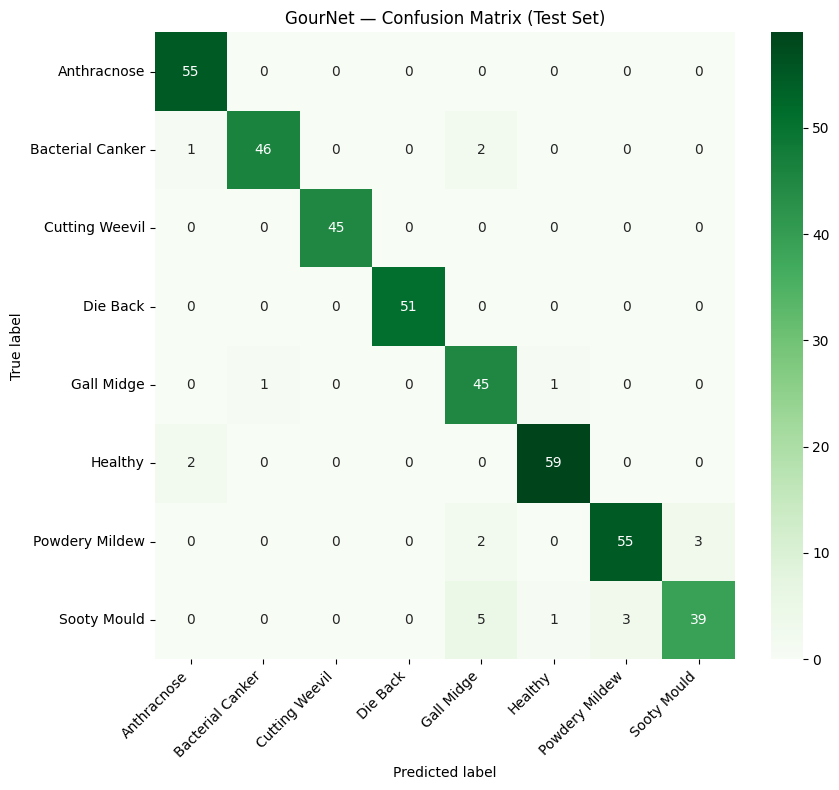

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("GourNet — Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("gournet_confusion_matrix.png", dpi=150)
plt.show()

In [13]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

                  precision    recall  f1-score   support

     Anthracnose     0.9483    1.0000    0.9735        55
Bacterial Canker     0.9787    0.9388    0.9583        49
  Cutting Weevil     1.0000    1.0000    1.0000        45
        Die Back     1.0000    1.0000    1.0000        51
      Gall Midge     0.8333    0.9574    0.8911        47
         Healthy     0.9672    0.9672    0.9672        61
  Powdery Mildew     0.9483    0.9167    0.9322        60
     Sooty Mould     0.9286    0.8125    0.8667        48

        accuracy                         0.9495       416
       macro avg     0.9505    0.9491    0.9486       416
    weighted avg     0.9513    0.9495    0.9493       416



## 8. Save the trained model

In [14]:
model.save("gournet_model.keras")
print("Saved trained model to gournet_model.keras")

Saved trained model to gournet_model.keras
